In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Loading Dataset

In [3]:
df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Dataset Overview

The dataset contains information about students including demographic factors, family background, study habits, and academic performance.

In [8]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## Missing Values Check

The dataset was checked for missing values using the `isnull().sum()` function.

All columns returned 0 missing values, indicating that the dataset is complete and no imputation or removal of missing data was required.

In [12]:
df.duplicated().sum()
df = df.drop_duplicates()

## Analysis Questions
<li>Average final grade (G3)</li>
<li>How many students scored above 15?</li>
<li>Is study time correlated with performance?</li>
<li>Which gender performs better on average?</li>

### 1) Average Final Grade
#### The average final grade represents the overall academic performance of students.

In [13]:
avg_grade = df['G3'].mean()

print("Average Final Grade:", round(avg_grade,2))

Average Final Grade: 10.42


### 2) How many students scored above 15?
#### Students scoring above 15 are considered high-performing students.

In [14]:
above_15 = df[df['G3'] > 15]

print("Students scoring above 15:", len(above_15))

Students scoring above 15: 40


### 3) Is study time correlated with final grades? 
#### The dataset documentation states: 
studytime <br>
1 = <2 hours <br>
2 = 2–5 hours <br>
3 = 5–10 hours <br>
4 = >10 hours <br>

In [15]:
correlation = df['studytime'].corr(df['G3'])

print("Correlation:", round(correlation,3))

Correlation: 0.098


#### A positive value indicates that increased study time tends to improve grades.

### 4) Which gender performs better on average?
#### The dataset defines:
F = Female
M = Male

In [16]:
gender_avg = df.groupby('sex')['G3'].mean()
print(gender_avg)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


#### Comparing average grades helps determine whether one gender performs better academically.

## Visualizations
<li> Histogram of grades </li>
<li> Scatterplot: study time vs grades </li>
<li> Bar chart: male vs female average score </li>

### 1) Histogram of Final Grades
#### The histogram shows how student grades are distributed.

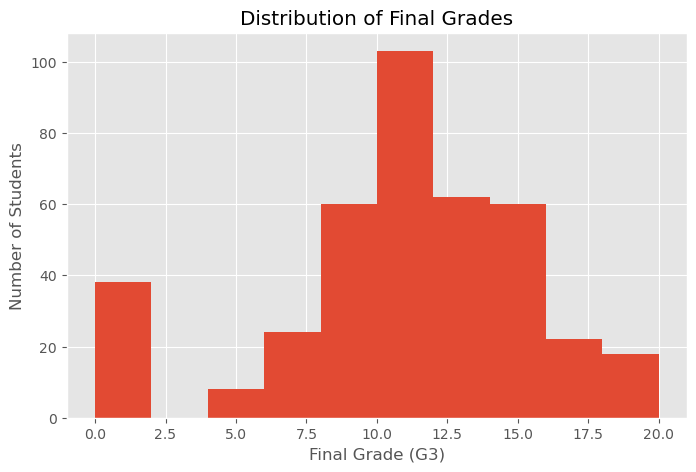

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df['G3'], bins=10)

plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')

plt.show()

### 2) Scatterplot: Study Time 
#### This scatter plot helps visualize the relationship between study habits and academic performance.

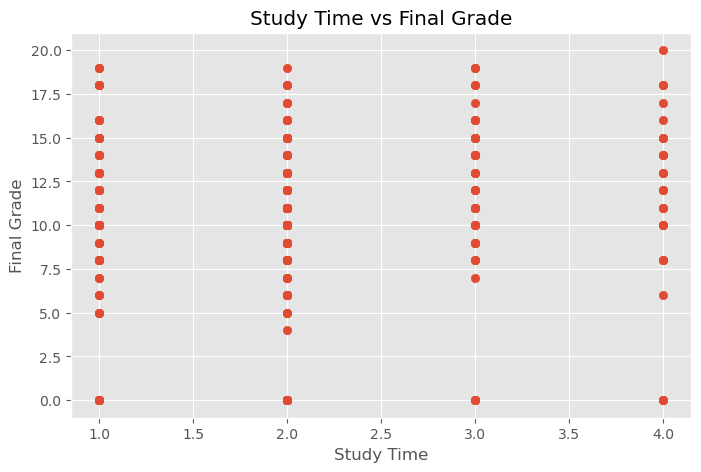

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df['studytime'], df['G3'])

plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')

plt.show()

### 3) Bar chart: male vs female average score
#### This chart compares average performance between male and female students.

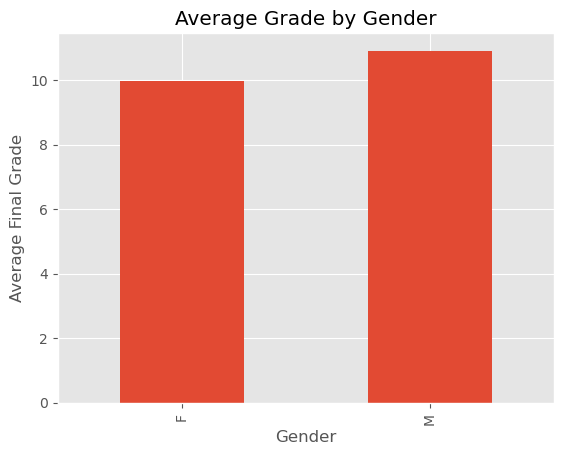

In [19]:
gender_avg.plot(kind='bar')

plt.title('Average Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Grade')

plt.show()

### 4) Absences vs Grades
#### This graph examines whether attendance influences academic performance.

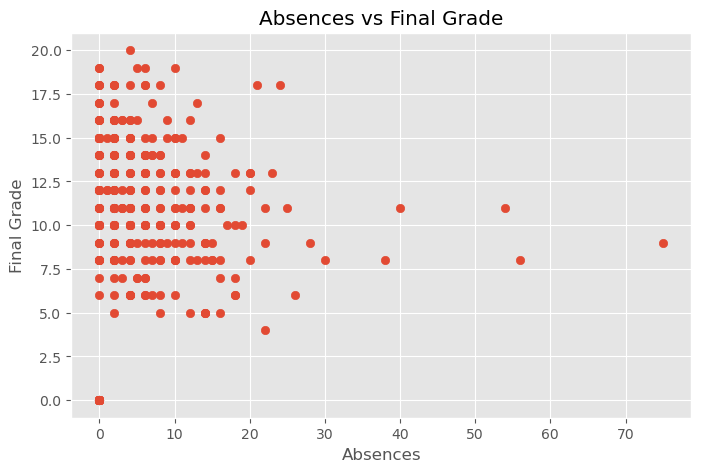

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df['absences'], df['G3'])

plt.title('Absences vs Final Grade')
plt.xlabel('Absences')
plt.ylabel('Final Grade')

plt.show()

## Additional Insights 

#### 1) Top 10 Students

In [21]:
top_students = df.sort_values('G3', ascending=False)

top_students[['age','sex','studytime','G3']].head(10)

,age,sex,studytime,G3
47,16,M,4,20
113,15,M,1,19
110,15,M,1,19
286,18,F,3,19
8,15,M,2,19
374,18,F,3,19
91,15,F,1,18
42,15,M,2,18
36,15,M,3,18
129,16,M,1,18


#### 2) Average Grade by Study Time

In [22]:
df.groupby('studytime')['G3'].mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

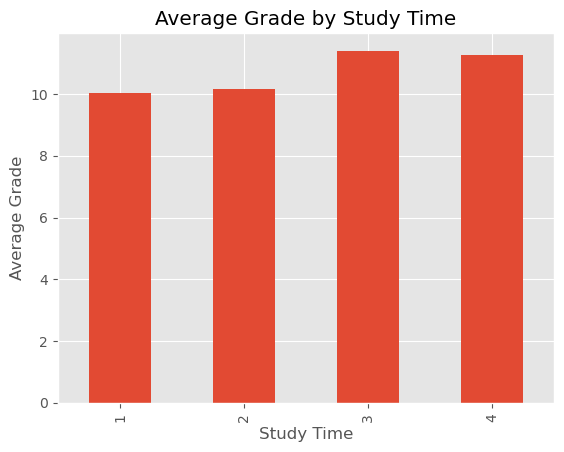

In [23]:
# Bar chart
df.groupby('studytime')['G3'].mean().plot(kind='bar')

plt.title("Average Grade by Study Time")
plt.xlabel("Study Time")
plt.ylabel("Average Grade")

plt.show()